In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Previous Notebook: `\Cleaning Scripts\2023-03-10 Additional Author Cleaning.ipynb`

In [2]:
# import papers_df
papers_df = pd.read_pickle('2023-03-28_NB3_papers_df_part3.pkl')

In [3]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16029 entries, 0 to 16028
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   first_auth       16029 non-null  object 
 1   second_auth      16029 non-null  object 
 2   third_auth       16029 non-null  object 
 3   Cites            16029 non-null  int16  
 4   ManuscriptTitle  16029 non-null  object 
 5   Year             16029 non-null  int16  
 6   CitesPerYear     16029 non-null  float16
 7   CitesPerAuthor   16029 non-null  float16
 8   AuthorCount      16029 non-null  int16  
 9   query_id         16029 non-null  int16  
 10  query_author     16029 non-null  object 
 11  PubTitle         16029 non-null  object 
 12  PubType          16029 non-null  object 
 13  SJR              16029 non-null  float64
 14  H index          16029 non-null  float16
 15  Country          16029 non-null  object 
 16  Region           16029 non-null  object 
 17  PubTier     

In [4]:
papers_df.head(3)

,first_auth,second_auth,third_auth,Cites,ManuscriptTitle,Year,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,query_author,PubTitle,PubType,SJR,H index,Country,Region,PubTier
0,d shi,valerio adinolfi,r comin,4186,low trapstate density and long carrier diffusi...,2015,523.000,523.0,8,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America,1
1,h tan,a jain,oleksandr voznyy,1951,efficient and stable solutionprocessed planar ...,2017,325.250,279.0,7,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America,1
2,b zhang,x zheng,oleksandr voznyy,1756,homogeneously dispersed multimetal oxygenevolv...,2016,250.875,251.0,7,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America,1


First, join the `papers_df` to the `query_df`

Need to find a way to cluster the individual authors

Need to expand the data set so that it has the form...


|Name |Title| ...|
|-----|--------|----|
|d shi|low trap-state density and| ...|
|v adinolfi	 |low trap-state density and| ...|
|r comin |low trap-state density and| ...|
|h tan	| efficient and stable solution-| ...|

In [5]:
def make_df(row):
    '''
    
    Parameters:
    ----------
    row: a Pandas Series that is a single row in the larger papers_df data frame. This row should contain
    information about the paper, including the columns 'first_auth', 'second_auth', 'third_auth'.
    
    Return:
    -------
    ret_df: a new data frame that has repeated information about each paper for each author. 
    It also has new columns 'AuthorName' and 'AuthorRank'
    
    '''
    
    # NumpPy Array of the author names
    auth_list = np.unique(row[['first_auth', 'second_auth', 'third_auth', 'query_author']].values)
    
    # Series of values exlcuding the first, second and third author columns
    new_ser = row.drop(['first_auth', 'second_auth', 'third_auth', 'query_author'])
    
    # Initiate a New Data Fame
    ret_df = pd.DataFrame()
    
    # Adding new rows to the data frame for each author in the paper
    for i in range(auth_list.shape[0]):
        auth_ser = pd.Series({'AuthorName': auth_list[i], 'AuthorRank': i+1})
        concat_ser = pd.concat([auth_ser, new_ser])
        
        concat_df = pd.DataFrame([concat_ser])
        ret_df = pd.concat([ret_df, concat_df], axis = 0)
    
    return ret_df

In [6]:
from tqdm.notebook import tqdm 

# Initiate DataFrame
new_df = pd.DataFrame()

# Adding new data frames (this takes about 4-5 minutes)
# Using a for loop instead of .apply() to be able to use the tqdm module to track the progress
for i in tqdm(range(papers_df.shape[0])):
    row = papers_df.loc[i, :]
    
    # Make a new set of dataframe
    ret_df = make_df(row)
     
    # Add to new df
    new_df = pd.concat([new_df, ret_df], axis = 0)

  0%|          | 0/16029 [00:00<?, ?it/s]

In [7]:
new_df = new_df.reset_index(drop = True)

Let's check for nulls

In [8]:
new_df.isna().sum()

AuthorName         0
AuthorRank         0
Cites              0
ManuscriptTitle    0
Year               0
CitesPerYear       0
CitesPerAuthor     0
AuthorCount        0
query_id           0
PubTitle           0
PubType            0
SJR                0
H index            0
Country            0
Region             0
PubTier            0
dtype: int64

In [9]:
rows, cols = new_df.shape
print(f'The new_df has {rows} rows and {cols} columns')

The new_df has 59032 rows and 16 columns


In [10]:
new_df.sample(3)

,AuthorName,AuthorRank,Cites,ManuscriptTitle,Year,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,PubTitle,PubType,SJR,H index,Country,Region,PubTier
37272,martin bonderup stergaard,1,29,temperaturedependent densification of sodium b...,2015,3.630859,5.0,6,229,rsc advances,journal,0.667,167.0,United Kingdom,Western Europe,2
46449,b sa,1,2,pressureinduced destabilization and anomalous ...,2017,0.330078,0.0,7,117,inorganic chemistry,journal,1.121,241.0,United States,Northern America,2
30896,pr bueno,3,42,relaxation processes in the coloration of amor...,2004,2.210938,11.0,4,15,journal of applied physics,journal,0.668,331.0,United States,Northern America,1


Now that we have the new data frame, we can more easily build a profile for each author.

In [11]:
num_df = new_df.groupby('AuthorName').size().reset_index(name='NumPapers_inDataset')
num_df

,AuthorName,NumPapers_inDataset
0,a a petrov,26
1,a aatiq,1
2,a abbas,2
3,a abbasi,1
4,a abdollahi,1
...,...,...
15853,zy xia,1
15854,zy xiao,1
15855,zy zhan,1
15856,zz dai,1


In [12]:
new_df.head(5)

,AuthorName,AuthorRank,Cites,ManuscriptTitle,Year,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,PubTitle,PubType,SJR,H index,Country,Region,PubTier
0,d shi,1,4186,low trapstate density and long carrier diffusi...,2015,523.00,523.0,8,0,science,journal,14.589,1229.0,United States,Northern America,1
1,edward sargent,2,4186,low trapstate density and long carrier diffusi...,2015,523.00,523.0,8,0,science,journal,14.589,1229.0,United States,Northern America,1
2,r comin,3,4186,low trapstate density and long carrier diffusi...,2015,523.00,523.0,8,0,science,journal,14.589,1229.0,United States,Northern America,1
3,valerio adinolfi,4,4186,low trapstate density and long carrier diffusi...,2015,523.00,523.0,8,0,science,journal,14.589,1229.0,United States,Northern America,1
4,a jain,1,1951,efficient and stable solutionprocessed planar ...,2017,325.25,279.0,7,0,science,journal,14.589,1229.0,United States,Northern America,1


In [13]:
sub_df = pd.concat([new_df.loc[:, 'AuthorName'], new_df.select_dtypes('number').drop('query_id', axis = 1)], axis = 1)

In [14]:
sub_df.groupby('AuthorName').agg(['mean', 'count', 'sum'])

AuthorRank                 Cites                      Year        \
                  mean count sum        mean count    sum         mean count   
AuthorName                                                                     
a a petrov         1.0    26  26   25.307692    26  658.0  2019.615385    26   
a aatiq            1.0     1   1    4.000000     1    4.0  2013.000000     1   
a abbas            1.0     2   2    3.500000     2    7.0  2021.500000     2   
a abbasi           1.0     1   1   54.000000     1   54.0  2016.000000     1   
a abdollahi        1.0     1   1  150.000000     1  150.0  2018.000000     1   
...                ...   ...  ..         ...   ...    ...          ...   ...   
zy xia             4.0     1   4   74.000000     1   74.0  2014.000000     1   
zy xiao            4.0     1   4   97.000000     1   97.0  2013.000000     1   
zy zhan            4.0     1   4   48.000000     1   48.0  2010.000000     1   
zz dai             4.0     1   4    6.000000     1    6.0  2022.000000     1   
zz ma              4.0     1   4   97.000000     1   97.0  2020.000000     1   

                     CitesPerYear  ... AuthorCount       SJR                \
                 sum         mean  ...         sum      mean count     sum   
AuthorName                         ...                                       
a a petrov   52510.0     6.089844  ...         152  1.390385    26  36.150   
a aatiq       2013.0     0.399902  ...           4  0.480000     1   0.480   
a abbas       4043.0     2.500000  ...          16  1.124500     2   2.249   
a abbasi      2016.0     7.710938  ...           5  0.464000     1   0.464   
a abdollahi   2018.0    30.000000  ...           4  8.663000     1   8.663   
...              ...          ...  ...         ...       ...   ...     ...   
zy xia        2014.0     8.218750  ...           7  0.682000     1   0.682   
zy xiao       2013.0     9.703125  ...          10  0.668000     1   0.668   
zy zhan       2010.0     3.689453  ...           8  1.025000     1   1.025   
zz dai        2022.0     6.000000  ...           7  3.225000     1   3.225   
zz ma         2020.0    32.343750  ...           9  1.744000     1   1.744   

             H index                 PubTier              
                mean count     sum      mean count   sum  
AuthorName                                                
a a petrov   184.375    26  4792.0  2.115385    26  55.0  
a aatiq      110.000     1   110.0  3.000000     1   3.0  
a abbas       92.000     2   184.0  2.500000     2   5.0  
a abbasi      80.000     1    80.0  3.000000     1   3.0  
a abdollahi  563.000     1   563.0  1.000000     1   1.0  
...              ...   ...     ...       ...   ...   ...  
zy xia        63.000     1    63.0  3.000000     1   3.0  
zy xiao      331.000     1   331.0  1.000000     1   1.0  
zy zhan      452.000     1   452.0  1.000000     1   1.0  
zz dai       259.000     1   259.0  2.000000     1   2.0  
zz ma        244.000     1   244.0  2.000000     1   2.0  

[15858 rows x 27 columns]

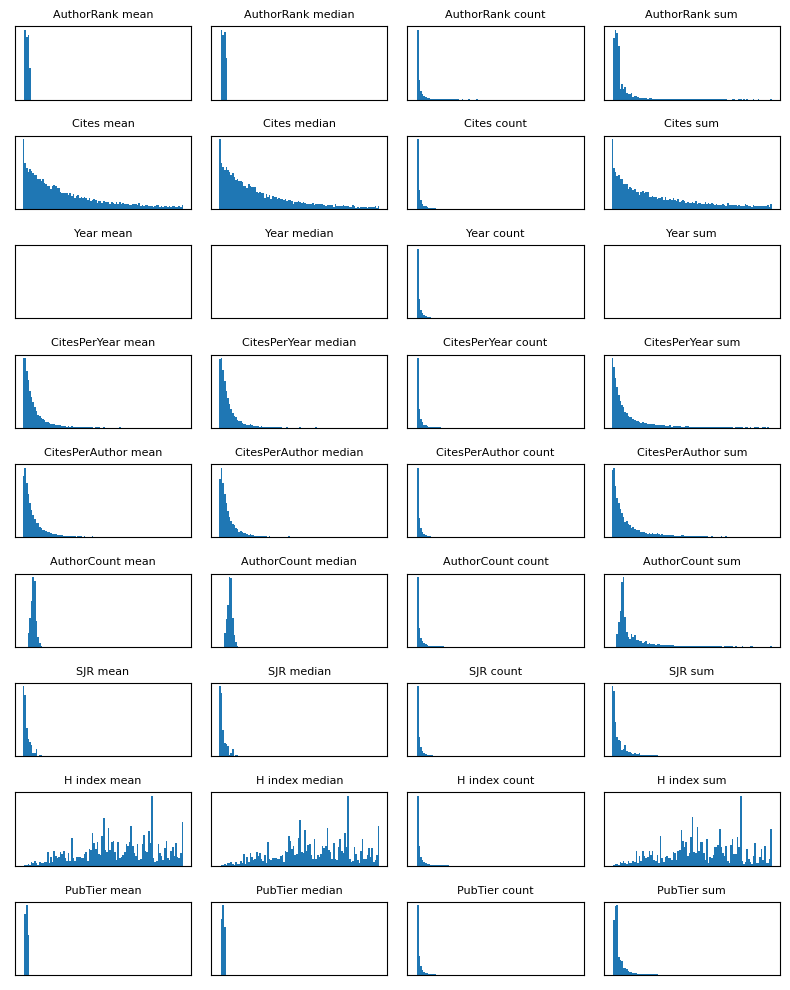

In [15]:
grouped_df = sub_df.groupby('AuthorName').agg(['mean', 'median', 'count', 'sum'])

level1_cols = sub_df.columns[1:]
level2_cols = ['mean', 'median', 'count', 'sum']

fig = plt.figure(figsize = (8, 10))
axes = fig.subplots(len(level1_cols), len(level2_cols))

i = 0 
for (row, col), ax in np.ndenumerate(axes):
    
    l1 = level1_cols[row]
    l2 = level2_cols[col]
    
    ax.hist(grouped_df[l1][l2], bins = 100, range = (0, 100))
    ax.set_title(f'{l1} {l2}', fontsize = 8)
    ax.set_xticks([],[])
    ax.set_yticks([],[])
    
    i += 1
    
fig.tight_layout()

It looks like, for the most part, the mean and median of each feature has a similar right-skew distribution as count and sum. The exceptions are `AuthorCount` and `AuthorRank` which have a move 'normal' distribution for the mean and median, and `Hindex` which has a more uniform distribution for mean, median and sum, but not count. For those reasons, for the final grouped dataset, let's chose to append the mean of the features for each author.

In [16]:
# Define new columns for the dataset
new_cols = np.asarray(['_'.join(['Mean', i]) for i in sub_df.groupby('AuthorName').mean().columns])
new_cols = ['AuthorName'] + np.where(new_cols == 'Mean_Hindex', 'Mean_SourceHindex', new_cols).tolist()

# Initiate new data frame
new_df2 = sub_df.groupby('AuthorName').mean().reset_index()

# Reset the columns names
new_df2.columns = new_cols

# Concat the Num column as well
new_df2 = pd.concat([new_df2, num_df.drop('AuthorName', axis= 1)], axis = 1)

new_df2.head()

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_Year,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SJR,Mean_H index,Mean_PubTier,NumPapers_inDataset
0,a a petrov,1.0,25.307692,2019.615385,6.089844,4.191406,5.846154,1.390385,184.375,2.115385,26
1,a aatiq,1.0,4.000000,2013.000000,0.399902,1.000000,4.000000,0.480000,110.000,3.000000,1
2,a abbas,1.0,3.500000,2021.500000,2.500000,0.000000,8.000000,1.124500,92.000,2.500000,2
3,a abbasi,1.0,54.000000,2016.000000,7.710938,11.000000,5.000000,0.464000,80.000,3.000000,1
4,a abdollahi,1.0,150.000000,2018.000000,30.000000,38.000000,4.000000,8.663000,563.000,1.000000,1


In [17]:
new_df2.isna().sum()

AuthorName             0
Mean_AuthorRank        0
Mean_Cites             0
Mean_Year              0
Mean_CitesPerYear      0
Mean_CitesPerAuthor    0
Mean_AuthorCount       0
Mean_SJR               0
Mean_H index           0
Mean_PubTier           0
NumPapers_inDataset    0
dtype: int64

In [18]:
def calculate_hindex(group):
    
    # An arr of the citations
    citations = group['Cites'].values.tolist()
    
    n = len(citations)
    citations.sort(reverse=True)
    h_index = 0
    
    for i in range(n):
        if citations[i] >= i+1:
            h_index = i+1
        else:
            break
    
    return h_index

In [19]:
grouped_df = sub_df.groupby('AuthorName')

# Get series of h index values
hindex_ser = grouped_df.apply(calculate_hindex).astype('int16').reset_index(name = 'Author_Hindex')

In [20]:
hindex_ser.isna().sum()

AuthorName       0
Author_Hindex    0
dtype: int64

Let's add `Author_Hindex` to the data frame

In [21]:
new_df1 = pd.concat([new_df2, pd.DataFrame(hindex_ser).drop('AuthorName', axis = 1)], axis = 1)

In [22]:
new_df1.head()

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_Year,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SJR,Mean_H index,Mean_PubTier,NumPapers_inDataset,Author_Hindex
0,a a petrov,1.0,25.307692,2019.615385,6.089844,4.191406,5.846154,1.390385,184.375,2.115385,26,12
1,a aatiq,1.0,4.000000,2013.000000,0.399902,1.000000,4.000000,0.480000,110.000,3.000000,1,1
2,a abbas,1.0,3.500000,2021.500000,2.500000,0.000000,8.000000,1.124500,92.000,2.500000,2,2
3,a abbasi,1.0,54.000000,2016.000000,7.710938,11.000000,5.000000,0.464000,80.000,3.000000,1,1
4,a abdollahi,1.0,150.000000,2018.000000,30.000000,38.000000,4.000000,8.663000,563.000,1.000000,1,1


In [23]:
new_df1.isna().sum()

AuthorName             0
Mean_AuthorRank        0
Mean_Cites             0
Mean_Year              0
Mean_CitesPerYear      0
Mean_CitesPerAuthor    0
Mean_AuthorCount       0
Mean_SJR               0
Mean_H index           0
Mean_PubTier           0
NumPapers_inDataset    0
Author_Hindex          0
dtype: int64

In [24]:
test_df = papers_df.copy()
test_auth_df = new_df1.copy()
og_auth_cols = test_auth_df.columns

for i in ['first_auth', 'second_auth', 'third_auth', 'query_author']:
    test_auth_df.columns = [og_auth_cols[0]] + [f'{i}_{j}'for j in og_auth_cols [1:]]
    test_df = pd.merge(left = test_df, right = test_auth_df, left_on = i, right_on = 'AuthorName')

C:\Users\kelly\AppData\Local\Temp\ipykernel_10264\2896091345.py:7: FutureWarning: Passing 'suffixes' which cause duplicate columns {'AuthorName_x'} in the result is deprecated and will raise a MergeError in a future version.
  test_df = pd.merge(left = test_df, right = test_auth_df, left_on = i, right_on = 'AuthorName')


In [25]:
ml_df = test_df.select_dtypes('number').drop('query_id', axis = 1)

In [26]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16029 entries, 0 to 16028
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Cites                             16029 non-null  int16  
 1   Year                              16029 non-null  int16  
 2   CitesPerYear                      16029 non-null  float16
 3   CitesPerAuthor                    16029 non-null  float16
 4   AuthorCount                       16029 non-null  int16  
 5   SJR                               16029 non-null  float64
 6   H index                           16029 non-null  float16
 7   PubTier                           16029 non-null  int8   
 8   first_auth_Mean_AuthorRank        16029 non-null  float64
 9   first_auth_Mean_Cites             16029 non-null  float64
 10  first_auth_Mean_Year              16029 non-null  float64
 11  first_auth_Mean_CitesPerYear      16029 non-null  float16
 12  firs

In [27]:
num_cols = ml_df.columns[8:]

for col in num_cols:
    max_val = ml_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    if max_val < 32E6:
        print(f'The type for {col} is being changed to float16')
        ml_df[col] = ml_df[col].astype('float16')
    print('\n')

The max value in the first_auth_Mean_AuthorRank column is 4.0
The type for first_auth_Mean_AuthorRank is being changed to float16


The max value in the first_auth_Mean_Cites column is 3788.0
The type for first_auth_Mean_Cites is being changed to float16


The max value in the first_auth_Mean_Year column is 2023.0
The type for first_auth_Mean_Year is being changed to float16


The max value in the first_auth_Mean_CitesPerYear column is 325.5
The type for first_auth_Mean_CitesPerYear is being changed to float16


The max value in the first_auth_Mean_CitesPerAuthor column is 586.0
The type for first_auth_Mean_CitesPerAuthor is being changed to float16


The max value in the first_auth_Mean_AuthorCount column is 12.0
The type for first_auth_Mean_AuthorCount is being changed to float16


The max value in the first_auth_Mean_SJR column is 18.718
The type for first_auth_Mean_SJR is being changed to float16


The max value in the first_auth_Mean_H index column is 1276.0
The type for first_aut

In [28]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16029 entries, 0 to 16028
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Cites                             16029 non-null  int16  
 1   Year                              16029 non-null  int16  
 2   CitesPerYear                      16029 non-null  float16
 3   CitesPerAuthor                    16029 non-null  float16
 4   AuthorCount                       16029 non-null  int16  
 5   SJR                               16029 non-null  float64
 6   H index                           16029 non-null  float16
 7   PubTier                           16029 non-null  int8   
 8   first_auth_Mean_AuthorRank        16029 non-null  float16
 9   first_auth_Mean_Cites             16029 non-null  float16
 10  first_auth_Mean_Year              16029 non-null  float16
 11  first_auth_Mean_CitesPerYear      16029 non-null  float16
 12  firs

Since our goal is to develop a model that can predict the publication tier of a manuscript based off of the author information alone, we need to remove the features that are not tied to author metrics. For `model_df`, those features will be `Cites`, `Year`, `CitesPerYear`, `CitesPerAuthor`, `AuthorCount`, `SJR` and `H index`. Let's remove those in `model_df` to get our final data frame.

In [29]:
ml_df = ml_df.drop(['Cites', 'Year', 'CitesPerAuthor', 'CitesPerYear', 'AuthorCount', 'SJR', 'H index'], axis = 1)

Here are the remaining columns in `ml_df`

In [31]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16029 entries, 0 to 16028
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   PubTier                           16029 non-null  int8   
 1   first_auth_Mean_AuthorRank        16029 non-null  float16
 2   first_auth_Mean_Cites             16029 non-null  float16
 3   first_auth_Mean_Year              16029 non-null  float16
 4   first_auth_Mean_CitesPerYear      16029 non-null  float16
 5   first_auth_Mean_CitesPerAuthor    16029 non-null  float16
 6   first_auth_Mean_AuthorCount       16029 non-null  float16
 7   first_auth_Mean_SJR               16029 non-null  float16
 8   first_auth_Mean_H index           16029 non-null  float16
 9   first_auth_Mean_PubTier           16029 non-null  float16
 10  first_auth_NumPapers_inDataset    16029 non-null  float16
 11  first_auth_Author_Hindex          16029 non-null  float16
 12  seco

The remaining columns in `ml_df`, besides the target column `PubTier` are of metrics associated with each author. Let's save this data frame as a pickle for implementation into machine learning models.

In [32]:
ml_df.to_pickle('2023-04-04_NB4_ml_df.pkl')

---